# Identification of factors

QUESTIONS: Heatmaps: Both plot_latent_dims_in_heatmap calls (Celltypist and available annotations) still use embed, so the heatmaps show one row per factor (no separate +/− rows). 

In this notebook, we use the already trained DRVI model on the immune dataset to identify biological processes captured by each latent factor. We combine multiple complementary annotation strategies:

1. **Cell type annotation** — match factors to known cell types using existing labels (SMI) and pre-trained classifiers (CellTypist)
2. **Annotation of Biological Processes** using
    * a. **Gene set enrichment analysis (GSEA)** — identify enriched pathways from ranked gene lists (BlitzGSEA)
    * b. **Over-representation analysis (ORA)** — test for enriched gene sets using ordered queries (g:Profiler)
    * c. **Regulator activity inference** — infer transcription factor or pathway activity using a statistical framework (decoupler) integrated with prior knowledge 

Each tool operates on the gene-level effect scores produced by DRVI's latent space traversal, which capture how gene expression changes when a latent factor is activated in either direction.

All tools in this notebook are **guiding tools**: they summarize large gene-level patterns into interpretable scores, but they do **not** provide definitive labels. Their outputs should always be interpreted in context, compared across methods, and validated against known biology and the original data.

**We always advise examination by a biologist and validation against published literature for any identified processes.**

## Intro

This notebook assumes that you have already trained a DRVI model and run the interpretability pipeline (latent space traversal).

Please refer to the [General training and interpretability pipeline](./general_pipeline.html) tutorial.

While we use the immune dataset as a running example, all code is dataset-agnostic. Configuration variables at the top of each section indicate what to change for your own data.

## Contact

For questions and help requests, you can reach out in the [scverse discourse](https://discourse.scverse.org/).

If you found a bug, please use the [issue tracker](https://github.com/theislab/drvi/issues).

## Adapting this notebook to your own dataset

To reuse this notebook on a different dataset or DRVI model, check and update the following items:

- **1. File paths and IO**
  - Update `io_dir` to point to your project directory.
  - Make sure the following files exist under `io_dir` with your data:
    - `adata_preprocesses.h5ad` (preprocessed AnnData with HVGs and UMAP)
    - `embed.h5ad` (DRVI latent embedding with `embed.var["title"]` and `embed.var["vanished"]`)
    - `traverse_adata.h5ad` (traversal results with `varm["combined_score_traverse_effect_pos/neg"]`)
    - Optionally: `immune_all.h5ad` (or your equivalent full-gene data) for defining `all_genes`.

- **2. Cell-level annotations (optional but recommended)**
  - If you have cell-type labels, set `annot_col` to the corresponding column in `adata.obs`
    (e.g. `"final_annotation"`).
  - If you do **not** have annotations, set `annot_col = None` and skip:
    - Section 1.1 (SMI with known annotations)
    - Section 5 (visual validation on UMAP).

- **3. Species and gene-sets**
  - For g:Profiler, set:
    - `organism` (e.g. `"hsapiens"`, `"mmusculus"`).
    - `gp_source` to the GO / pathway collections you care about (e.g. `["GO:BP"]`, `["REAC"]`).
  - For decoupler, set:
    - `dc_geneset` (e.g. `"collectri"`, `"dorothea"`, `"progeny"` or another resource name).
    - `dc_organism` to match your species (e.g. `"human"`, `"mouse"`).
  - For non-human species, check that your gene-set resources and all_genes use the same gene-name casing; you may need to remove .str.upper() when working with mouse.

- **4. CellTypist (optional)**
  - Choose a model via `ct_model` that matches your tissue / species
    (e.g. `"Immune_All_Low.pkl"` for PBMC, `"Developing_Mouse_Brain.pkl"` for mouse brain).
  - If no suitable model exists, skip the CellTypist section and rely on your own annotations
    plus the enrichment / decoupler tools using celltype databases.

- **5. Significance thresholds**
  - `fdr_threshold` controls:
    - FDR cutoffs for BlitzGSEA and decoupler.
    - The g:SCS-corrected p-value cutoff in g:Profiler (treated analogously to an FDR threshold).

- **6. Manual curation**
  - Use the exported `factor_annotation_curation.csv` as your central place to:
    - Inspect top genes and tool suggestions per factor-direction.
    - Define `MANUAL_LABELS` and `MANUAL_NOTES` in the helper cell.
  - Re-import the curated CSV and re-run the final cells to store
    `embed.var["annotation_final"]` and `embed.var["annotation_source"]` with your labels.

## Install

If you try DRVI on colab, the next cell will install dependencies.

Please remove this part if your environment is already set up.

In [ ]:
import sys
import subprocess

branch = "latest"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB and branch == "stable":
    subprocess.check_call([sys.executable, "-m", "pip", "install", "drvi[tutorials]"])
elif IN_COLAB and branch != "stable":
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "git+https://github.com/theislab/drvi.git#egg=drvi[tutorials]"])

if IN_COLAB:
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "celltypist", "blitzgsea", "gprofiler-official", "decoupler"])

## Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

import scvi
import drvi
from pathlib import Path
from drvi.model import DRVI

In [4]:
print("Last run with scvi-tools version:", scvi.__version__)
print("Last run with DRVI version:", drvi.__version__)

Last run with scvi-tools version: 1.4.1
Last run with DRVI version: 0.2.2


In [5]:
# Making plots prettier
sc.settings.set_figure_params(dpi=100, frameon=False)
sc.set_figure_params(figsize=(3, 3))
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (3, 3)

## Config

In [ ]:
# Set input output directory
# We use tmp_io/ directory in the same place as this notebook. Update accordingly.
io_dir = Path("/home/icb/clara.sanchez/data/drvi_immune_128")


# Global significance threshold used across all tools.
# Note: for BlitzGSEA and decoupler this is an FDR cutoff, while for g:Profiler
# it is applied to g:SCS-corrected p-values (not classical FDR).
fdr_threshold = 0.05

## Load Data

In [7]:
# We already saved pre-processed data in previous notebook
adata = sc.read_h5ad(io_dir / "adata_preprocesses.h5ad")
adata

AnnData object with n_obs × n_vars = 32484 × 2000
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue'
    uns: 'batch_colors', 'final_annotation_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

## Load DRVI outputs

In [59]:
model_path = io_dir / "drvi_model"
embed_path = io_dir / "embed.h5ad"
traverse_adata_path = io_dir / "traverse_adata.h5ad"

model = DRVI.load(model_path, adata)
embed = sc.read_h5ad(embed_path)
traverse_adata = sc.read_h5ad(traverse_adata_path)

INFO     File /home/icb/clara.sanchez/data/drvi_immune_128/drvi_model/model.pt already downloaded                  
INFO     DRVI: The model is trained with DRVI version 0.2.1.                                                       
INFO     DRVI: Updaging data setup config ...                                                                      
INFO     DRVI: Done updating data source registry. Loading in DRVI version 0.2.2.                                  
INFO     DRVI: Loading model from DRVI version 0.2.1.                                                              
INFO     DRVI: Modifying model args from 0.2.1 to 0.2.2 (no user action required)                                  
INFO     DRVI: Removing prior_init_obs from model args.                                                            
INFO     DRVI: Done updating model args. Loading in 0.2.2.                                                         
INFO     DRVI: The model has been initialized                           

## 0. Prepare shared inputs

All annotation tools operate on the gene-level effect scores from DRVI's latent space traversal. For each latent factor, traversing in the positive (+) or negative (−) direction produces a vector of per-gene scores that quantify how much each gene's predicted expression changes. These scores serve as:

- **Ranked gene lists** for GSEA-style tools (BlitzGSEA)
- **Ordered gene queries** for ORA-style tools (g:Profiler)
- **Gene × factor score matrices** for decoupler which uses statistical models (like ULM or MLR) to infer regulator activity by integrating these scores with a prior knowledge network

We prepare these shared inputs once and reuse them across all tools.

In [ ]:
# Remove vanished dimensions
embed_nv = embed[:, ~embed.var["vanished"].astype(bool)].copy()
factor_ids = embed_nv.var["title"].astype(str).tolist()
print(f"Active (non-vanished) factors: {embed_nv.n_vars}")

# Extract per-gene traverse effect scores (genes x factors)
# These capture how gene expression changes when each latent factor is traversed
pos_df = traverse_adata.varm["o"].copy()
neg_df = traverse_adata.varm["combined_score_traverse_effect_neg"].copy()

# Filter to non-vanished dimensions
vanished_mask = ~embed.var["vanished"].astype(bool).values
if pos_df.shape[1] == len(vanished_mask):
    pos_df = pos_df.iloc[:, vanished_mask].copy()
    neg_df = neg_df.iloc[:, vanished_mask].copy()

pos_df.columns = factor_ids
neg_df.columns = factor_ids

# Background gene universe: all genes measured in the experiment (before HVG filtering).
raw_data_path = io_dir / "immune_all.h5ad"  
adata_full = sc.read_h5ad(raw_data_path, backed="r")

# Background gene universe: all genes measured in the experiment (before HVG filtering).
# NOTE: We uppercase gene names here, which is appropriate for human (HUGO symbols),
# but will break standard mouse Gene Symbols (e.g., "Cd4" -> "CD4").
# If you work with mouse or another species where case matters, remove `.str.upper()`
# and make sure your gene set resources use the same casing as your data.
all_genes = adata_full.var_names.astype(str).str.strip().str.upper()
adata_full.file.close()
all_genes = pd.Index(all_genes).drop_duplicates().tolist()
print(f"Background genes: {len(all_genes)}")

Active (non-vanished) factors: 61
Background genes: 12303


In [10]:
# Build enrichment inputs from a genes x factors score matrix

# Returns
# std : DataFrame: Standardized genes x factors scores (uppercased, duplicates merged by max).
# ranked : dict {factor: Series sorted by descending score} for GSEA tools.

def build_inputs(df, all_genes=all_genes):
    std = df.copy()
    std.index = std.index.astype(str).str.strip().str.upper()
    std = std.groupby(std.index).max()

    if all_genes is not None:
        idx = pd.Index(pd.Series(all_genes).astype(str)).drop_duplicates()
        std = std.reindex(idx)

    ranked = {c: std[c].dropna().sort_values(ascending=False) for c in std.columns}
    return std, ranked


pos_std, pos_ranked = build_inputs(pos_df)
neg_std, neg_ranked = build_inputs(neg_df)

# Factor-direction labels used throughout (e.g., "DR 36+")
factor_dir_labels = [f"{f}+" for f in factor_ids] + [f"{f}-" for f in factor_ids]

print(f"Factors: {len(factor_ids)}")
print(f"Factor-directions: {len(factor_dir_labels)}")
print(f"Genes per ranked list: {len(next(iter(pos_ranked.values())))}")

Factors: 61
Factor-directions: 122
Genes per ranked list: 2000


## 1. Cell type annotation

Some latent factors capture cell-type identity. We can identify these using:
- **Known annotations** (if available): measure alignment between factors and annotated cell types via Scaled Mutual Information (SMI)
- **CellTypist**: classify cells using pre-trained models and correlate class probabilities with factor activities

#### Cell Type Annotation Config

In [ ]:
# Column in adata.obs containing cell type labels. Set to None if not available.
annot_col = "final_annotation" 

smi_threshold = 0.5 # Minimum SMI score between factor and cell-type probability profiles to consider a factor as associated with a cell type. Adjust as needed.

### 1.1 Known annotations (SMI)

If your dataset has existing cell type annotations, Scaled Mutual Information (SMI) measures how well each latent factor aligns with each annotated category. SMI is normalized to [0, 1], where 1 indicates perfect correspondence between a factor and a cell type.

In this dataset we have annotations stored in `adata.obs["final_annotation"]`.

We first measure Scaled Mutual Information (SMI) between each latent dimension and each category using DRVI built-in functions.

**Skip this section if your dataset does not have cell type annotations.**

#### Specific Imports

In [12]:
import math
import networkx as nx
from drvi.utils.metrics import DiscreteDisentanglementBenchmark

#### Scaled Mutual Information

In [83]:
# SMI is computed separately for positive and negative directions of each factor.

benchmark_pos = DiscreteDisentanglementBenchmark(
    embed_nv.X,
    dim_titles=embed_nv.var["title"],
    discrete_target=embed.obs[annot_col],
    metrics=["SMI-disc"],
    aggregation_methods=["LMS"],
)
benchmark_pos.evaluate()
smi_pos = benchmark_pos.get_results_details()["SMI-disc"]
smi_pos.index = [f"{t}+" for t in smi_pos.index]

benchmark_neg = DiscreteDisentanglementBenchmark(
    -embed_nv.X,
    dim_titles=embed_nv.var["title"],
    discrete_target=embed.obs[annot_col],
    metrics=["SMI-disc"],
    aggregation_methods=["LMS"],
)
benchmark_neg.evaluate()
smi_neg = benchmark_neg.get_results_details()["SMI-disc"]
smi_neg.index = [f"{t}-" for t in smi_neg.index]

smi_similarity = pd.concat([smi_pos, smi_neg], axis=0)
smi_similarity.index.name = "title"

# You can optionally save benchmark object if you want.
# benchmark.save(filename)

In [84]:
print(f"SMI matrix shape: {smi_similarity.shape} (factor-directions x cell types)")
display(smi_similarity.head())

SMI matrix shape: (122, 16) (factor-directions x cell types)


,CD4+ T cells,CD8+ T cells,CD10+ B cells,CD14+ Monocytes,CD16+ Monocytes,CD20+ B cells,Erythrocytes,Erythroid progenitors,HSPCs,Megakaryocyte progenitors,Monocyte progenitors,Monocyte-derived dendritic cells,NK cells,NKT cells,Plasma cells,Plasmacytoid dendritic cells
title,,,,,,,,,,,,,,,,
DR 36+,0.021124,0.007055,0.013579,0.005682,0.003340,0.006009,0.012808,0.025647,0.141675,0.147504,0.652945,0.023091,0.009346,0.006856,0.019912,0.010587
DR 49+,0.058937,0.010312,0.003151,0.115108,0.019689,0.012800,0.006262,0.002189,0.002379,0.001219,0.001292,0.004543,0.008689,0.017035,0.859131,0.003900
DR 33+,0.030350,0.011059,0.030578,0.021986,0.009531,0.011717,0.048552,0.468666,0.061815,0.370950,0.022623,0.007081,0.010243,0.011877,0.009066,0.005726
DR 38+,0.017637,0.007678,0.008826,0.008149,0.012777,0.123699,0.004518,0.050416,0.004173,0.049967,0.008930,0.026165,0.005970,0.006707,0.018673,0.009291
DR 2+,0.140299,0.080318,0.033397,0.761070,0.048512,0.084590,0.070976,0.036295,0.033788,0.033796,0.033385,0.107270,0.063494,0.064894,0.035367,0.038994


In [85]:
smi_top_matches = (
    smi_similarity.reset_index()
    .melt(id_vars="title", value_vars=smi_similarity.columns)
    .query("value >= @smi_threshold")
    .reset_index(drop=True)
)
print(f"Factor–cell type pairs with SMI >= {smi_threshold}: {len(smi_top_matches)}")
display(smi_top_matches.sort_values("value", ascending=False))

Factor–cell type pairs with SMI >= 0.5: 48


,title,variable,value
47,DR 17-,Plasmacytoid dendritic cells,0.929396
46,DR 17+,Plasmacytoid dendritic cells,0.929396
45,DR 28-,Plasma cells,0.914106
43,DR 28+,Plasma cells,0.914106
13,DR 9+,CD16+ Monocytes,0.910748
15,DR 9-,CD16+ Monocytes,0.910748
11,DR 3-,CD14+ Monocytes,0.878655
9,DR 3+,CD14+ Monocytes,0.878655
44,DR 49-,Plasma cells,0.859131
42,DR 49+,Plasma cells,0.859131


#### Visualize with a Heatmap

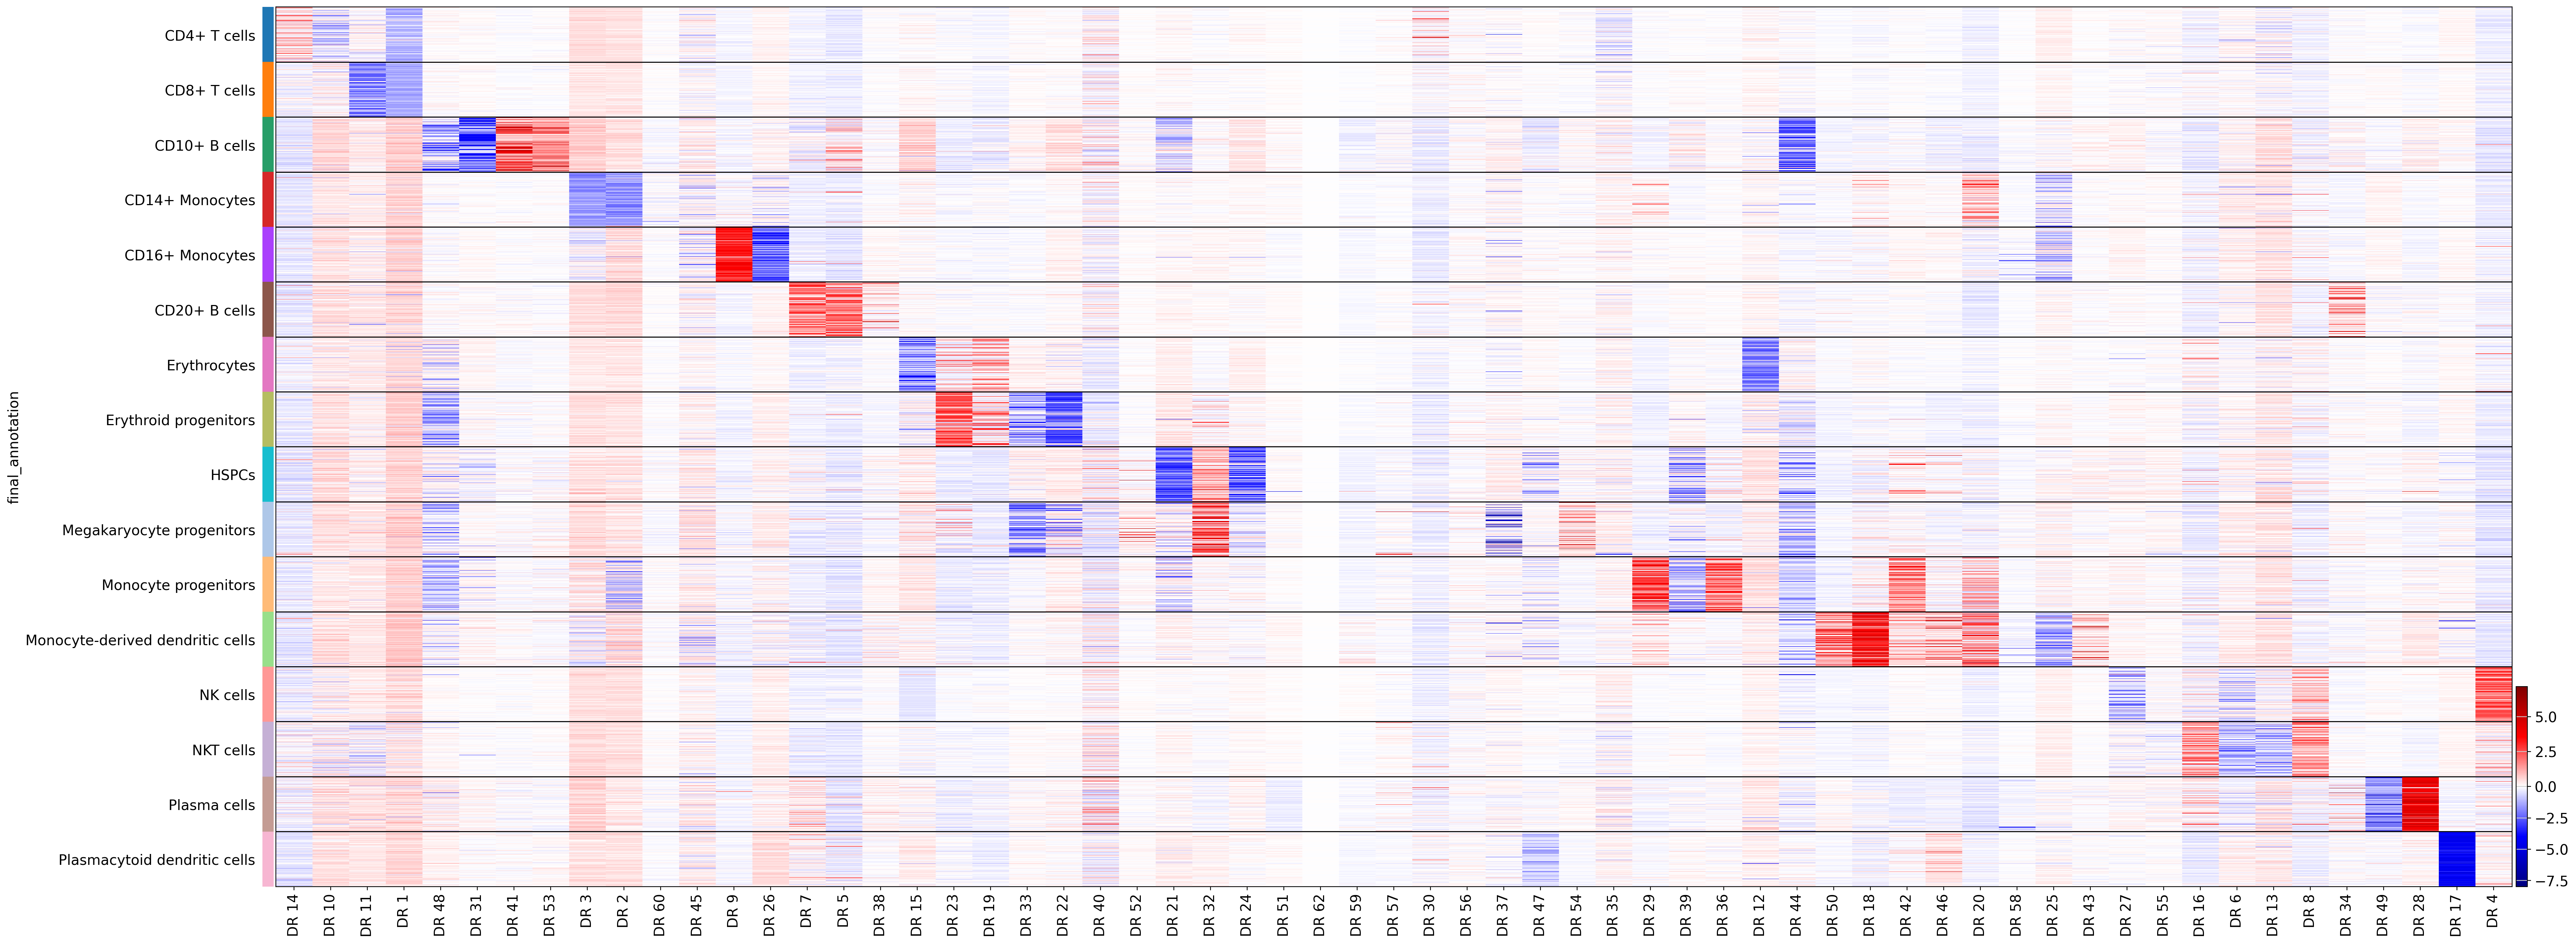

In [79]:
drvi.utils.pl.plot_latent_dims_in_heatmap(
    embed, 
    annot_col, 
    title_col="title", 
    sort_by_categorical=True,
    figsize=(40, 16),
    show=False,
)

fig = plt.gcf()
for ax in fig.axes:
    for label in ax.get_xticklabels():
        label.set_fontsize(14)
    for label in ax.get_yticklabels():
        label.set_fontsize(14)

plt.tight_layout()
plt.savefig("heatmap_large.png", dpi=150, bbox_inches="tight")
plt.show()

#### Helper function for Plot Packed Network Visualization

In [80]:
def plot_packed_network(df, title_col="title", var_col="variable", val_col="value"):
    """Visualizes factor–cell type associations as a network with edge weights."""
    G = nx.from_pandas_edgelist(df, title_col, var_col, edge_attr=val_col)

    pos = {}
    components = sorted(nx.connected_components(G), key=len, reverse=True)
    cols = math.ceil(len(components) ** 0.5)
    for i, nodes in enumerate(components):
        sub_pos = nx.spring_layout(G.subgraph(nodes), weight=val_col, k=0.5, seed=42)
        r, c = divmod(i, cols)
        for n, (x, y) in sub_pos.items():
            pos[n] = (x + c * 3, y - r * 3)

    plt.figure(figsize=(14, 10))
    titles = set(df[title_col])
    nx.draw(
        G, pos,
        with_labels=True, font_size=8, font_weight="bold", node_size=600,
        node_color=["#A0CBE2" if n in titles else "#FF9E9E" for n in G.nodes()],
        width=[d[val_col] * 4 for u, v, d in G.edges(data=True)],
        edge_color="grey", alpha=0.6,
    )
    edge_labels = {(u, v): f"{d[val_col]:.2f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    plt.axis("off")
    plt.show()

#### Plot Packed Visualization

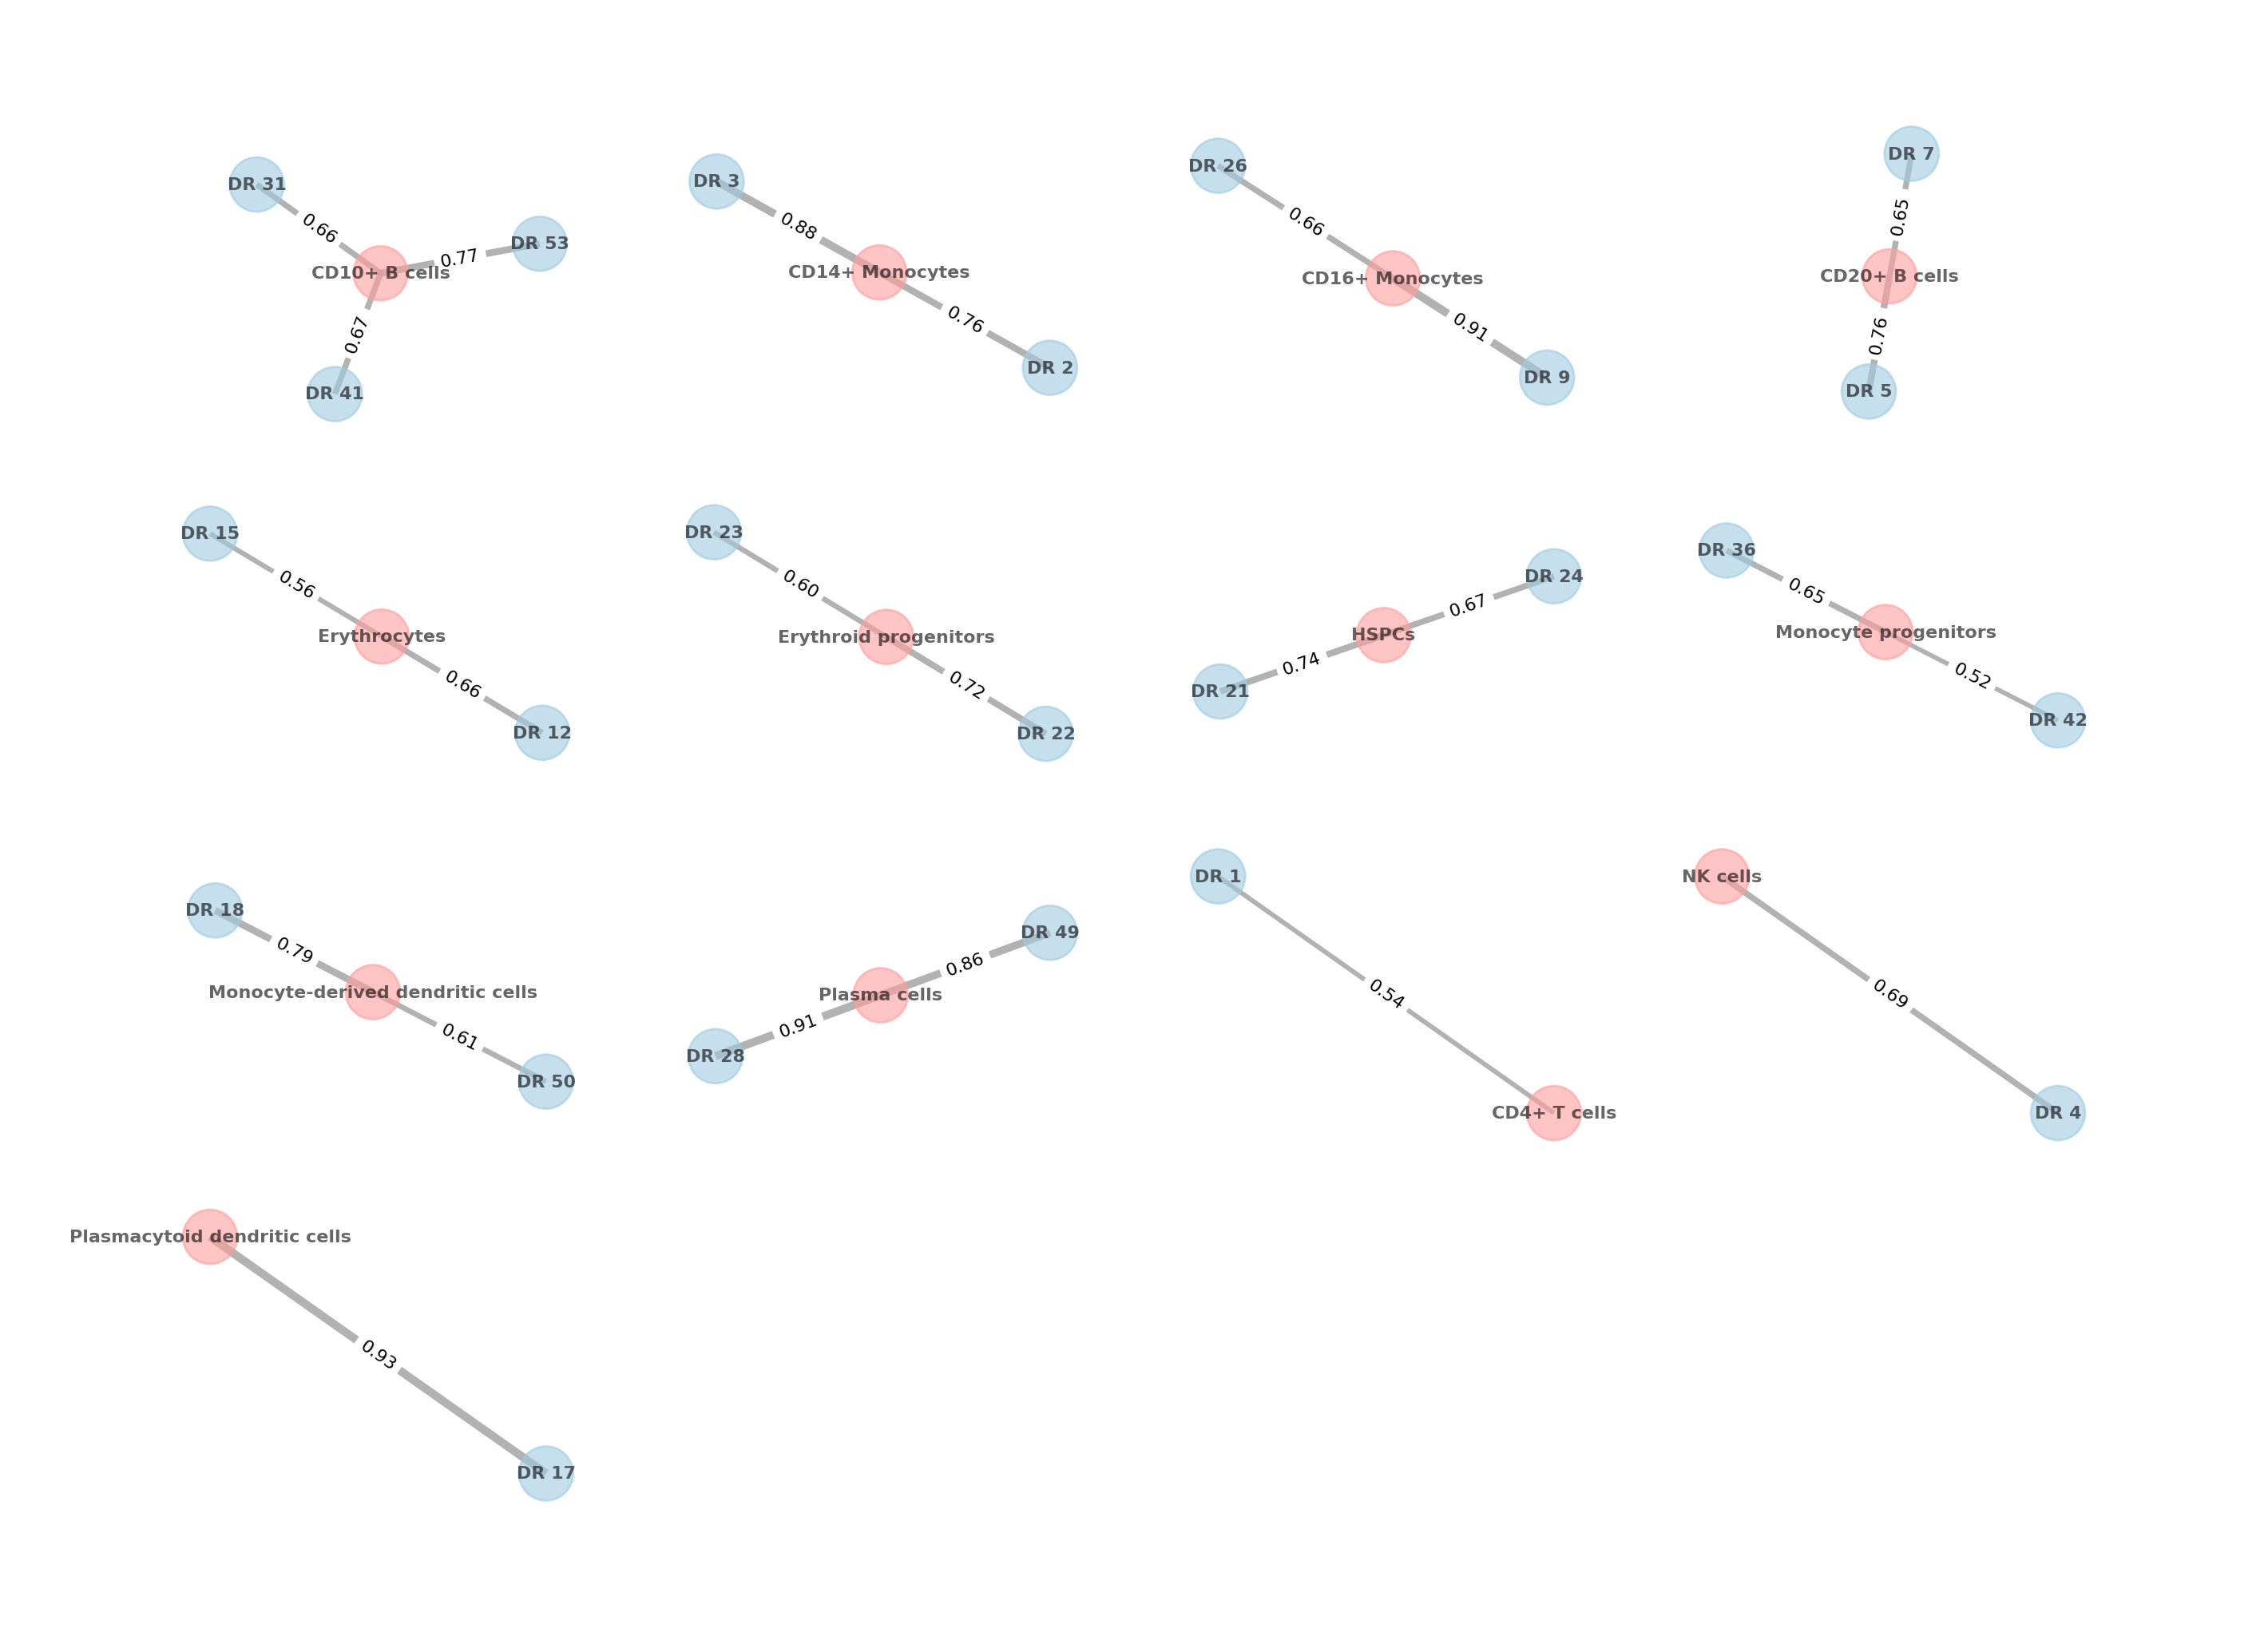

In [18]:
plot_packed_network(smi_top_matches)

### 1.2 CellTypist

[CellTypist](https://www.celltypist.org/) uses pre-trained logistic regression models trained on large-scale annotated atlases to classify individual cells. We calculate the Similarity Mutual Information (SMI) between the CellTypist probability matrix (cells × cell types) and the DRVI factor activity matrix (cells × factors) to identify which factors correspond to which cell types.

**Skip this section if no CellTypist model matches your tissue.**


#### Imports

In [19]:
import celltypist
from celltypist import models

#### CellTypist Model

In [20]:
# Run celltypist.models.models_description() to see all available models. Choose one matching your tissue. 
ct_model = "Immune_All_Low.pkl"  # e.g., "Developing_Mouse_Brain.pkl" for mouse brain
models.download_models(force_update=False, model=ct_model)

#load model
ct_model = models.Model.load(model=ct_model)

#  Run print(CT_MODEL.cell_types) to see cell types from the model

📂 Storing models in /home/icb/clara.sanchez/.celltypist/data/models
💾 Total models to download: 1
⏩ Skipping [1/1]: Immune_All_Low.pkl (file exists)


#### CellTypist Annotation

In [21]:
# 1. Each cell receives a predicted label via logistic regression based on its transcriptomic profile.
# 2. majority_voting=True refines these labels by assigning the most frequent label within a cell's local neighborhood (kNN), reducing technical noise.

# Output: per-cell labels are extracted from the predictions object and stored in adata.obs.
predictions = celltypist.annotate(adata, model=ct_model, majority_voting=True)
adata.obs["celltypist_labels"] = predictions.predicted_labels["predicted_labels"]
adata.obs["celltypist_majority"] = predictions.predicted_labels["majority_voting"]

⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate
🔬 Input data has 32484 cells and 2000 genes
🔗 Matching reference genes in the model
🧬 1569 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 15
🗳️ Majority voting the predictions
✅ Majority voting done!


#### Extract Probability Matrix

In [22]:
# Probability matrix: sigmoid-transformed decision scores (cells x cell types)
prob_matrix = predictions.probability_matrix
prob_matrix.index = adata.obs_names
print(f"Probability matrix: {prob_matrix.shape[0]} cells x {prob_matrix.shape[1]} cell types")

Probability matrix: 32484 cells x 98 cell types


#### CellTypist Mutual Information

In [81]:
# SMI for CellTypist is computed separately for positive and negative directions (same as known annotations).
ct_benchmark_pos = DiscreteDisentanglementBenchmark(
    embed_nv.X,
    dim_titles=embed_nv.var["title"],
    discrete_target=adata.obs.loc[embed_nv.obs_names, "celltypist_majority"],
    metrics=["SMI-disc"],
    aggregation_methods=["LMS"],
)
ct_benchmark_pos.evaluate()
ct_smi_pos = ct_benchmark_pos.get_results_details()["SMI-disc"]
ct_smi_pos.index = [f"{t}+" for t in ct_smi_pos.index]

ct_benchmark_neg = DiscreteDisentanglementBenchmark(
    -embed_nv.X,
    dim_titles=embed_nv.var["title"],
    discrete_target=adata.obs.loc[embed_nv.obs_names, "celltypist_majority"],
    metrics=["SMI-disc"],
    aggregation_methods=["LMS"],
)
ct_benchmark_neg.evaluate()
ct_smi_neg = ct_benchmark_neg.get_results_details()["SMI-disc"]
ct_smi_neg.index = [f"{t}-" for t in ct_smi_neg.index]

ct_smi_matrix = pd.concat([ct_smi_pos, ct_smi_neg], axis=0)
ct_smi_matrix.index.name = "factor"
print(f"CellTypist SMI matrix: {ct_smi_matrix.shape} (factor-directions x CellTypist labels)")

CellTypist SMI matrix: (122, 24) (factor-directions x CellTypist labels)


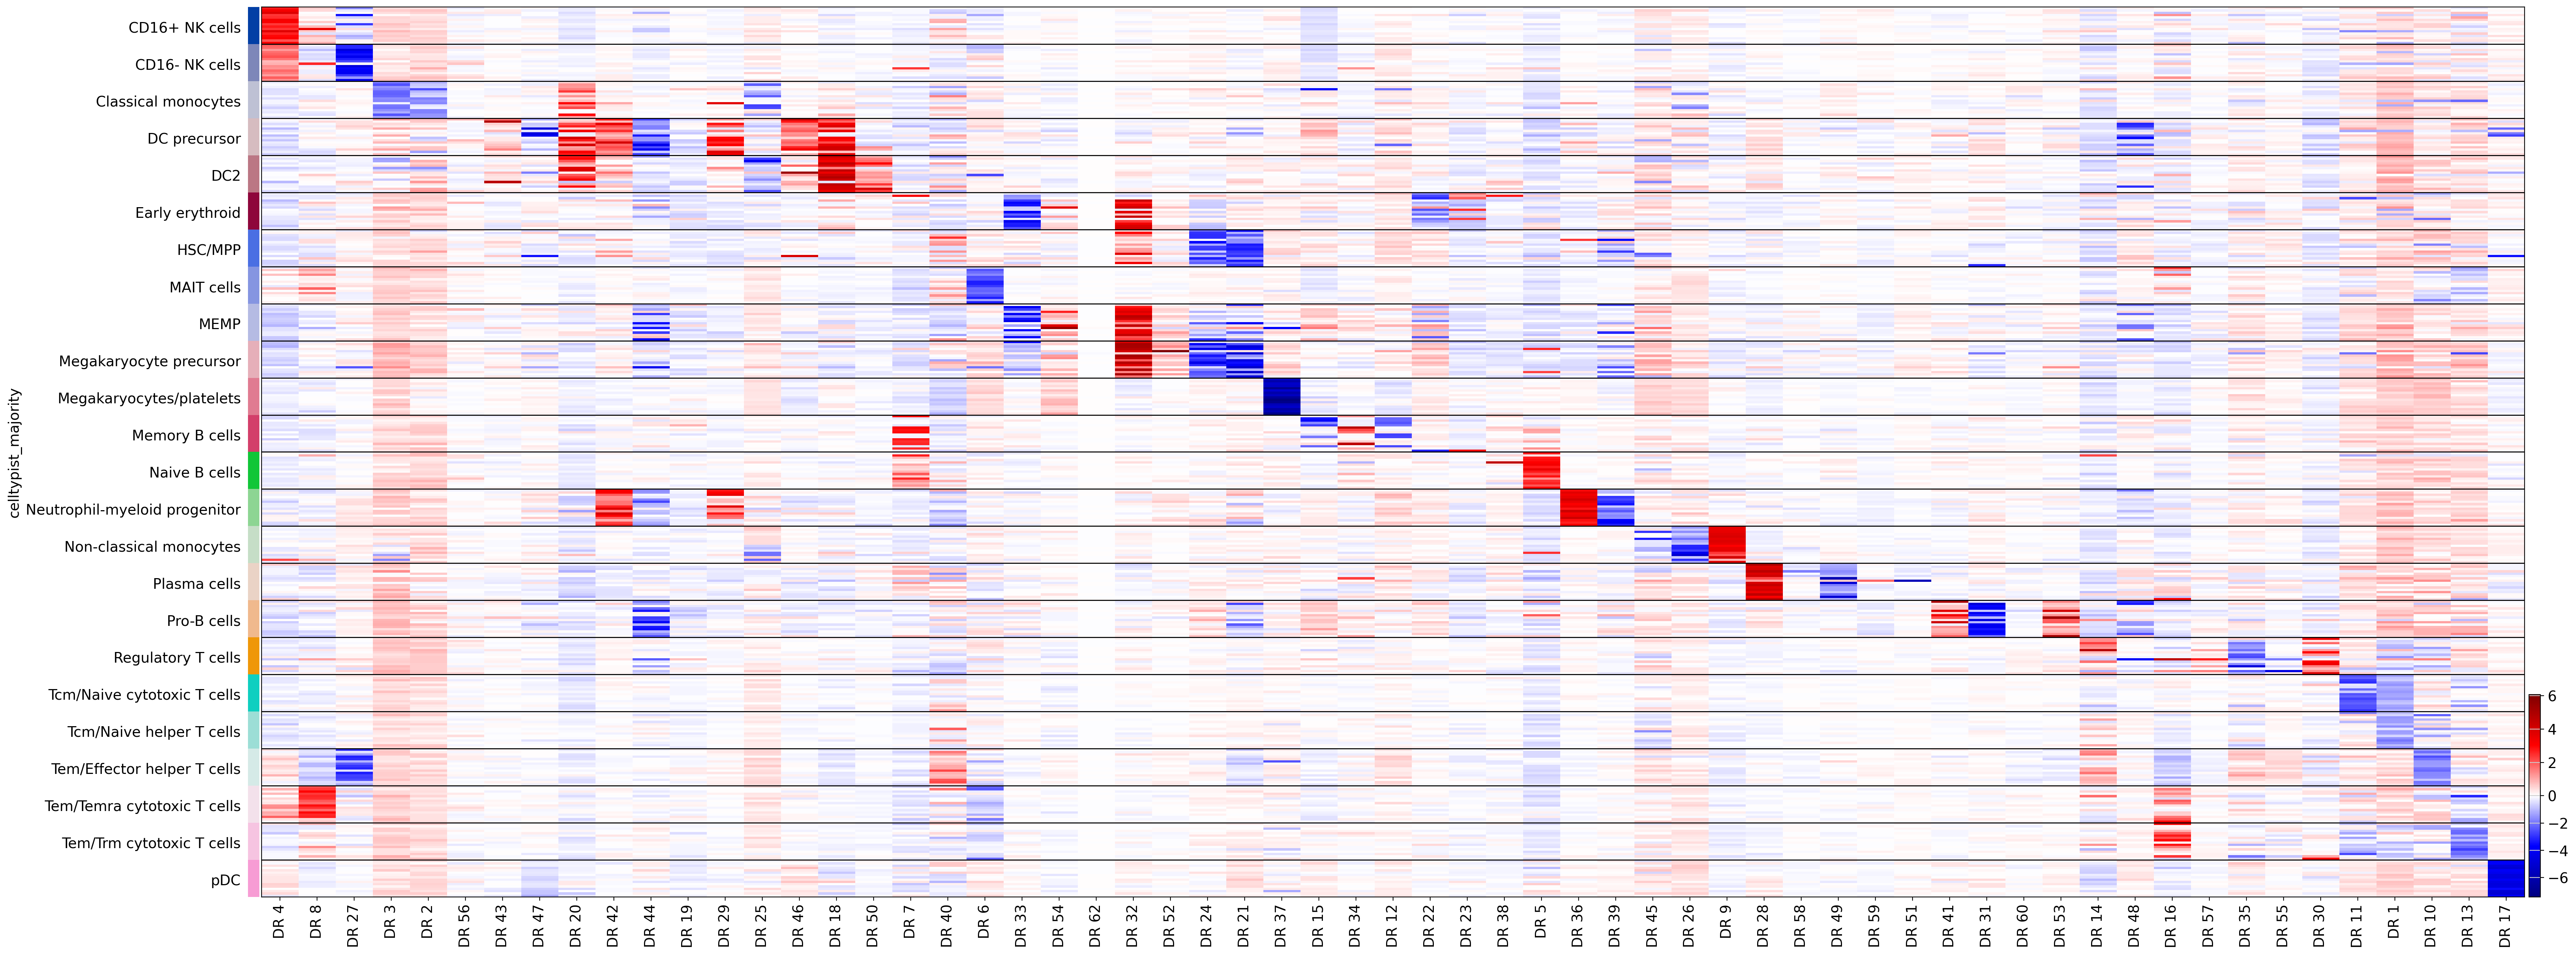

In [61]:
common_cells = adata.obs_names.intersection(embed.obs_names)
embed = embed[common_cells].copy()
adata = adata[common_cells].copy()

embed.obs["celltypist_majority"] = (
    adata.obs["celltypist_majority"]
    .reindex(embed.obs_names)
)

drvi.utils.pl.plot_latent_dims_in_heatmap(
    embed, 
    "celltypist_majority", 
    title_col="title", 
    sort_by_categorical=True,
    figsize=(40, 16),
    show=False,  
)

fig = plt.gcf()
for ax in fig.axes:
    for label in ax.get_xticklabels():
        label.set_fontsize(14)
    for label in ax.get_yticklabels():
        label.set_fontsize(14)

plt.tight_layout()
plt.savefig("heatmap_large.png", dpi=150, bbox_inches="tight")
plt.show()

#### Summary Table

In [ ]:
# Top CellTypist match per factor-direction
idx_name = ct_smi_matrix.index.name or "index"
ct_long = (
    ct_smi_matrix.reset_index()
    .melt(id_vars=idx_name, var_name="cell_type", value_name="smi")
    .rename(columns={idx_name: "factor"})
    .sort_values("smi", ascending=False)
    .drop_duplicates(subset="factor", keep="first")
)

ct_significant = ct_long.query("smi >= @smi_threshold").copy()

print(
    f"CellTypist matches with SMI >= {smi_threshold}: "
    f"{len(ct_significant)} / {len(ct_long)} factors"
)

CellTypist matches with SMI >= 0.5: 29 / 122 factor-directions


,factor,cell_type,smi
2915,DR 17-,pDC,0.957552
1283,DR 37-,Megakaryocytes/platelets,0.914588
1932,DR 28+,Plasma cells,0.913778
78,DR 4+,CD16+ NK cells,0.881255
1828,DR 9+,Non-classical monocytes,0.872452
1586,DR 36+,Neutrophil-myeloid progenitor,0.823990
291,DR 3-,Classical monocytes,0.821163
1498,DR 5+,Naive B cells,0.811494
829,DR 21-,HSC/MPP,0.804409
1833,DR 49-,Plasma cells,0.794328


## 2. Biological process identification

Factors that do not map to a single cell type often capture biological processes (e.g., interferon response, cell cycle, stress). We use three complementary enrichment approaches, each with different strengths:

| Tool | Method | Input | Strengths |
|------|--------|-------|-----------|
| **BlitzGSEA** | Pre-ranked GSEA | Full ranked gene list | Fast; uses entire ranking; uses an analytical null distribution |
| **g:Profiler** | Over-representation (ORA) | Ordered gene query | Robust multiple-testing (g:SCS); well-suited for biological pathways and GO terms |
| **decoupler** | Activity Inference (ULM/MLM) | Gene score matrix + Prior Knowledge | Regression-based; identifies specific regulatory drivers (e.g., TFs) using curated networks |

### 2.1 BlitzGSEA

[BlitzGSEA](https://github.com/MaayanLab/blitzgsea) performs pre-ranked Gene Set Enrichment Analysis using an analytical approximation of the null distribution rather than permutations, enabling high-performance enrichment testing across many factors.

- **Input**: Full ranked gene list (genes sorted by their DRVI effect scores, capturing the magnitude and direction of expression change)
- **Output**: Normalized Enrichment Score (NES) and FDR-adjusted p-values per gene set
- **Database**: Compatible with any standard .gmt file or Enrichr library (e.g., MSigDB, Reactome)

In [66]:
# Enrichr library to use. See Appendix for available databases.
# Common choices: "MSigDB_Hallmark_2020", "GO_Biological_Process_2023",
#                 "Reactome_2022", "KEGG_2021_Human"

gsea_db = "GO_Biological_Process_2023"

In [67]:
import blitzgsea as blitz

signature_lib = blitz.enrichr.get_library(gsea_db)
print(f"Loaded {gsea_db}: {len(signature_lib)} gene sets")

Loaded GO_Biological_Process_2023: 5407 gene sets


In [68]:
blitzgsea_rows = []

for fac in factor_ids:
    for direction, ranked_dict in [("pos", pos_ranked), ("neg", neg_ranked)]:
        factor_label = f"{fac}+" if direction == "pos" else f"{fac}-"
        series = ranked_dict[fac]

        # BlitzGSEA expects a DataFrame with columns "i" (gene) and "v" (score)
        signature = series.rename("v").reset_index().rename(columns={"index": "i"})
        signature["v"] = pd.to_numeric(signature["v"], errors="coerce")
        signature = signature.replace([np.inf, -np.inf], np.nan).dropna(subset=["v"])

        try:
            res = blitz.gsea(signature, signature_lib, processes=4)
            sig = res[res["fdr"] < fdr_threshold].sort_values("fdr")
            if len(sig):
                # Keep up to the top 3 most significant terms per factor-direction
                top_sig = sig.head(3)
                for term, row in top_sig.iterrows():
                    blitzgsea_rows.append({
                        "factor": factor_label,
                        "term": term,
                        "NES": round(float(row["nes"]), 3),
                        "FDR": float(row["fdr"]),
                    })
        except Exception as e:
            print(f"BlitzGSEA failed for {factor_label}: {e}")

blitzgsea_results = pd.DataFrame(blitzgsea_rows)
print(
    f"BlitzGSEA significant directions: {blitzgsea_results['factor'].nunique()} / {len(factor_dir_labels)} "
    f"(with up to 3 terms per direction)"
)
display(blitzgsea_results.sort_values(["factor", "FDR"]))

BlitzGSEA failed for DR 36-: The function value at x=nan is NaN; solver cannot continue.
BlitzGSEA failed for DR 49+: The function value at x=nan is NaN; solver cannot continue.
BlitzGSEA failed for DR 33+: The function value at x=nan is NaN; solver cannot continue.
BlitzGSEA failed for DR 38-: The function value at x=nan is NaN; solver cannot continue.
BlitzGSEA failed for DR 2+: The function value at x=nan is NaN; solver cannot continue.
BlitzGSEA failed for DR 41-: The function value at x=nan is NaN; solver cannot continue.
BlitzGSEA failed for DR 57-: The function value at x=nan is NaN; solver cannot continue.
BlitzGSEA failed for DR 59-: The function value at x=nan is NaN; solver cannot continue.
BlitzGSEA failed for DR 55+: The function value at x=nan is NaN; solver cannot continue.
BlitzGSEA failed for DR 62+: The function value at x=nan is NaN; solver cannot continue.
BlitzGSEA failed for DR 62-: The function value at x=nan is NaN; solver cannot continue.
BlitzGSEA failed for D

,factor,term,NES,FDR
21,DR 1-,Immunoglobulin Production Involved In Immunogl...,-5.829,0.000009
22,DR 1-,Peptide Antigen Assembly With MHC Class II Pro...,-5.580,0.000010
23,DR 1-,MHC Class II Protein Complex Assembly (GO:0002...,-5.580,0.000010
117,DR 10-,Immunoglobulin Production Involved In Immunogl...,-5.283,0.000215
118,DR 10-,Peptide Antigen Assembly With MHC Class II Pro...,-4.977,0.000273
...,...,...,...,...
61,DR 60-,Peptide Antigen Assembly With MHC Class II Pro...,-5.564,0.000011
62,DR 60-,Peptide Antigen Assembly With MHC Protein Comp...,-5.564,0.000011
75,DR 8+,Positive Regulation Of Protein Tyrosine Kinase...,-5.204,0.000328
76,DR 8+,Muscle Organ Development (GO:0007517),-4.889,0.000856


### 2.2 g:Profiler

[g:Profiler](https://biit.cs.ut.ee/gprofiler/) performs Over-Representation Analysis (ORA) using a hypergeometric test. It employs a custom multiple-testing correction (g:SCS), which is specifically optimized to handle the hierarchical and overlapping structure of Gene Ontology terms.

In **ordered query** mode, g:Profiler processes genes sorted by their DRVI effect scores and iteratively tests enrichment at increasing increments. This approach automatically identifies the optimal gene set size for enrichment, making it more sensitive than using a fixed "top-N" cutoff for continuous latent factor scores.

How it works:
- **Input**: Ordered gene list (genes sorted by absolute or directional traverse effect scores)
- **Output**: Enriched terms with p-values corrected via g:SCS
- **Database**: Comprehensive support for GO (BP, MF, CC), Reactome, KEGG, WikiPathways, and regulatory motifs

Many functional annotation collections (for example Gene Ontology, pathway databases, or phenotype ontologies) are hierarchical and redundant. Broad "umbrella" terms tend to be enriched across multiple latent factors, while more specific child terms capture finer-grained biology. Because of this structure, there is rarely a single automatically chosen term that is clearly "the" correct label for a factor.

In this tutorial, we therefore treat g:Profiler as a tool to obtain **shortlists of enriched terms per factor-direction**, not as an automatic source of single-factor labels.

When annotating factors, you can:
- Use g:Profiler's ranked terms as *additional context* alongside CellTypist, BlitzGSEA, decoupler, and the top genes
- Manually pick specific, interpretable terms that best describe each factor-direction (for example, in this immune dataset, `T cell activation` or `mononuclear cell differentiation`)

In [32]:
# Organism string. Common values: "hsapiens", "mmusculus", "drerio"
organism = "hsapiens"

# Source database(s).
# Common choices: ["GO:BP"], ["GO:MF"], ["GO:CC"], ["REAC"], ["KEGG"], ["HP"]
gp_source = ["GO:BP"]

In [33]:
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)


def run_gprofiler_for_factor(genes, factor_label):
    """Run g:Profiler ordered-query ORA for a single factor-direction."""
    genes = pd.Series(genes).dropna().astype(str).drop_duplicates().tolist()
    if not genes:
        return pd.DataFrame()

    res = gp.profile(
        organism=organism,
        query=genes,
        sources=gp_source,
        ordered=True,
        user_threshold=fdr_threshold,
        background=all_genes,
    )
    if res is None or res.empty:
        return pd.DataFrame()

    res = res.copy()
    res["factor"] = factor_label
    return res

In [75]:
gprofiler_parts = []

for fac in factor_ids:
    for direction, ranked_dict in [("pos", pos_ranked), ("neg", neg_ranked)]:
        factor_label = f"{fac}+" if direction == "pos" else f"{fac}-"
        genes = ranked_dict[fac].index.tolist()
        gprofiler_parts.append(run_gprofiler_for_factor(genes, factor_label))

gprofiler_all = pd.concat(
    [x for x in gprofiler_parts if not x.empty], ignore_index=True
) if any(not x.empty for x in gprofiler_parts) else pd.DataFrame()

sig = gprofiler_all[gprofiler_all["p_value"] < fdr_threshold].copy()
print(
    f"g:Profiler results: {len(sig)} significant rows across "
    f"{sig['factor'].nunique()} factor-directions "
    f"(g:SCS-corrected p < {fdr_threshold})."
)

AssertionError: query failed with error 504

#### Explore top pathway terms per factor-direction

In [35]:
# Example: "DR 2+", "DR 36-", etc.
factor_to_inspect = "DR 2+"
top_n_gp_terms = 10  # or 5, as you prefer

if not gprofiler_all.empty:
    available = sorted(gprofiler_all["factor"].unique())
    print(f"Available factor-directions ({len(available)}): {available[:10]}{' ...' if len(available) > 10 else ''}\n")

    df_fac = gprofiler_all[
        (gprofiler_all["factor"] == factor_to_inspect)
        & (gprofiler_all["p_value"] < fdr_threshold)
    ].copy()

    if df_fac.empty:
        print(f"No significant g:Profiler terms for factor {factor_to_inspect} at this threshold.")
    else:
        df_fac = (
            df_fac.sort_values("p_value")
            [["factor", "name", "p_value", "intersection_size", "term_size"]]
            .rename(columns={"name": "term"})
            .head(top_n_gp_terms)
        )
        print(f"Top {len(df_fac)} g:Profiler terms for {factor_to_inspect}:")
        display(df_fac)
else:
    print("gprofiler_all is empty — run the g:Profiler enrichment cell above first.")

Available factor-directions (122): ['DR 1+', 'DR 1-', 'DR 10+', 'DR 10-', 'DR 11+', 'DR 11-', 'DR 12+', 'DR 12-', 'DR 13+', 'DR 13-'] ...

Top 10 g:Profiler terms for DR 2+:


,factor,term,p_value,intersection_size,term_size
2865,DR 2+,cell activation,1.847839e-54,382,899
2866,DR 2+,leukocyte activation,1.455025e-47,334,786
2867,DR 2+,lymphocyte activation,4.103303e-44,284,669
2868,DR 2+,regulation of immune system process,7.500935e-42,451,1215
2869,DR 2+,regulation of cell activation,4.534444e-38,234,510
2870,DR 2+,positive regulation of immune system process,7.398691e-38,339,868
2871,DR 2+,T cell activation,2.718610e-36,215,481
2872,DR 2+,regulation of leukocyte activation,1.487108e-33,208,466
2873,DR 2+,regulation of lymphocyte activation,1.671778e-32,190,420
2874,DR 2+,regulation of immune response,2.215286e-31,293,756


### 2.3 decoupler

[decoupler](https://decoupler-py.readthedocs.io/) uses regression-based methods (Univariate/Multivariate Linear Models, z-score) and weighted sums to infer the activity of regulators from gene-level scores. Unlike enrichment-based methods, it models the relationship between observed gene scores and a Prior Knowledge Network (PKN), quantifying the specific influence of a regulator.

decoupler provides access to curated regulatory resources from [OmniPath](https://omnipathdb.org/):

- **CollecTRI**: Comprehensive transcription factor (TF) → target gene interactions, well-suited for discovering TF-level drivers of latent factors.
- **DoRothEA**: TF regulons categorized by confidence levels (A–D) based on supporting evidence; also TF-centric, with tunable stringency.
- **PROGENy**: Pathway footprints that infer upstream pathway activity (e.g., Hypoxia, EGFR, TGFb) from downstream responsive genes.

For DRVI latent factor annotation, **CollecTRI and DoRothEA are usually the most informative options**, because latent factors can capture TF-driven gene programs or cell identity signatures. **PROGENy can still be used as an exploratory option**, but in practice it may yield few or no strongly significant hits when factors are not dominated by a small set of canonical signaling pathways (as in this immune example).

Multiple decoupler methods are run in parallel and combined via a consensus step to produce robust p-values.

In [36]:
# Gene set / network to use.
# Recommended options for factor annotation: "collectri", "dorothea".
# PROGENy ("progeny") is more pathway-focused and may give few strong hits
# if latent factors are not dominated by canonical signaling pathways.
dc_geneset = "collectri"  # or "dorothea"

# Organism. Must match ORGANISM above: "human" for hsapiens, "mouse" for mmusculus
dc_organism = "human"

dc_methods = ["ulm", "mlm", "zscore"]
dc_min = 5 # Minimum number of genes from the gene set that must be present in the data for a valid enrichment test.

In [37]:
import decoupler as dc
from statsmodels.stats.multitest import multipletests

In [38]:
net_dispatch = {
    "collectri": lambda: dc.op.collectri(organism=dc_organism),
    "dorothea": lambda: dc.op.dorothea(organism=dc_organism, levels=["A", "B", "C"]),
    "progeny": lambda: dc.op.progeny(organism=dc_organism),
}
net = net_dispatch.get(
    dc_geneset.strip().lower(),
    lambda: dc.op.resource(name=dc_geneset, organism=dc_organism),
)()

cols = ["source", "target"] + (["weight"] if "weight" in net.columns else [])
net = net[cols].dropna().drop_duplicates().reset_index(drop=True)
print(f"Network: {len(net)} interactions, {net['source'].nunique()} regulators")

Network: 42990 interactions, 1185 regulators


In [70]:
def run_decouple(df_factors_by_genes, direction_label):
    """Run decoupler consensus on a factors x genes score matrix."""
    mat = df_factors_by_genes.copy()
    mat.columns = mat.columns.astype(str).str.strip().str.upper()
    # keep only genes that exist in the PKN and in our data
    targets = net["target"].astype(str).str.strip().str.upper().unique()
    keep_cols = [g for g in mat.columns if g in targets]
    mat = mat[keep_cols]
    mat = mat.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    net_use = net.copy()
    net_use["target"] = net_use["target"].astype(str).str.strip().str.upper()

    res = dc.mt.decouple(
        data=mat,
        net=net_use,
        methods=dc_methods,
        cons=False,
        tmin=dc_min,
        verbose=False,
    )
    _, pvals = dc.mt.consensus(res)

    out = pvals.stack().rename("p_value").reset_index()
    out.columns = ["factor_raw", "term", "p_value"]

    # BH correction for FDR comparability with other tools
    _, p_adj, _, _ = multipletests(out["p_value"].values, method="fdr_bh")
    out["p_adj"] = p_adj

    suffix = "+" if direction_label == "pos" else "-"
    out["factor"] = out["factor_raw"].astype(str) + suffix
    return out[["factor", "term", "p_value", "p_adj"]]


dec_pos = run_decouple(pos_std.T, "pos")
dec_neg = run_decouple(neg_std.T, "neg")
decoupler_all = pd.concat([dec_pos, dec_neg], ignore_index=True)

# Keep significant top-1 per factor-direction
decoupler_results = (
    decoupler_all[decoupler_all["p_adj"] < fdr_threshold]
    .sort_values("p_adj")
    .groupby("factor", as_index=False)
    .first()
    [["factor", "term", "p_adj"]]
)

print(
    f"decoupler significant regulators for "
    f"{decoupler_results['factor'].nunique()} / {len(factor_dir_labels)} factor-directions "
    f"(top 1 regulator per direction with FDR < {fdr_threshold})"
)
display(decoupler_results.sort_values("p_adj"))

decoupler significant regulators for 34 / 122 factor-directions (top 1 regulator per direction with FDR < 0.05)


,factor,term,p_adj
5,DR 18+,NR1H2,2.764783e-23
25,DR 5-,MAFK,3.975272e-22
22,DR 47-,NR0B2,8.248736e-18
32,DR 6-,RORC,1.063270e-17
4,DR 17-,RARG,1.500825e-17
6,DR 20-,MITF,2.863583e-16
29,DR 54-,CREB5,7.280742e-15
31,DR 58-,GATA1,6.423957e-12
24,DR 49-,POU2AF1,6.638785e-11
30,DR 55-,KLF11,1.248052e-10


## 3. Curation table and export

We now merge evidence from all tools into a single curation table. Each row represents one factor-direction, with the top hit from each tool (if significant) shown in a compact format. The table also includes the top 10 genes driving each factor-direction to facilitate manual validation via literature or LLMs.

**Recommended workflow (code-based labeling):**
1. Run the curation cells below to build the table and export a CSV template.
2. Edit `MANUAL_LABELS` (and optionally `MANUAL_NOTES`) in the helper cell to define your final annotations per factor-direction.
3. Re-run the curation and export cells to refresh the CSV with your labels.
4. Run the re-import cell to store final annotations in the embedding object.

Editing the CSV in an external editor is possible, but re-running the export cell will overwrite any external edits. Code-based edits in `MANUAL_LABELS` are safer and reproducible.

In [82]:
# Build the base table: all factor-directions with top 10 genes
curation_rows = []
for fac in factor_ids:
    for direction, ranked_dict in [("pos", pos_ranked), ("neg", neg_ranked)]:
        factor_label = f"{fac}+" if direction == "pos" else f"{fac}-"
        top_genes = ", ".join(ranked_dict[fac].head(10).index.tolist())
        curation_rows.append({"factor": factor_label, "top_genes": top_genes})

curation = pd.DataFrame(curation_rows)

# Known-annotation SMI (section 1.1): top cell-type match per factor-direction
known_map = {}
if len(smi_top_matches):
    for fac in curation["factor"].unique():
        sub = smi_top_matches[smi_top_matches["title"] == fac]
        if len(sub):
            row = sub.loc[sub["value"].idxmax()]
            known_map[fac] = f"{row['variable']} || SMI={row['value']:.2f}"
curation["known_annotation"] = curation["factor"].map(known_map).fillna("")

# CellTypist column (per factor-direction SMI; directions already in ct_significant)
ct_map = {}
if len(ct_significant):
    for _, row in ct_significant.iterrows():
        label = f"{row['cell_type']} || SMI={row['smi']:.2f}"
        ct_map[row["factor"]] = label
curation["celltypist"] = curation["factor"].map(ct_map).fillna("")

# BlitzGSEA column (up to 3 top terms per factor-direction)
bg_map = {}
if len(blitzgsea_results):
    for _, row in blitzgsea_results.iterrows():
        bg_map[row["factor"]] = f"{row['term']} || NES={row['NES']} || FDR={row['FDR']:.2e}"
curation["blitzgsea"] = curation["factor"].map(bg_map).fillna("")

# g:Profiler column (left empty for manual use; see Section 3.2)
curation["gprofiler"] = ""

# decoupler column
dc_map = {}
if len(decoupler_results):
    for _, row in decoupler_results.iterrows():
        dc_map[row["factor"]] = f"{row['term']} || p_adj={row['p_adj']:.2e}"
curation["decoupler"] = curation["factor"].map(dc_map).fillna("")

# Empty columns for manual curation (filled later via MANUAL_LABELS at import time)
curation["manual_label"] = ""
curation["manual_notes"] = ""

display(curation)

,factor,top_genes,known_annotation,celltypist,blitzgsea,gprofiler,decoupler,manual_label,manual_notes
0,DR 36+,"AZU1, ELANE, CTSG, CLEC5A, MGST1, MS4A3, S100P...",Monocyte progenitors || SMI=0.65,Neutrophil-myeloid progenitor || SMI=0.82,Peptide Antigen Assembly With MHC Protein Comp...,,,,
1,DR 36-,"HES4, ISG15, TNFRSF18, TNFRSF4, MIB2, MMP23B, ...",Monocyte progenitors || SMI=0.65,,,,,,
2,DR 49+,"HES4, ISG15, TNFRSF18, TNFRSF4, MIB2, MMP23B, ...",Plasma cells || SMI=0.86,,,,,,
3,DR 49-,"TNFRSF17, HRASLS2, IGLL5, TNFRSF13B, PKHD1L1, ...",Plasma cells || SMI=0.86,Plasma cells || SMI=0.79,MHC Class II Protein Complex Assembly (GO:0002...,,POU2AF1 || p_adj=6.64e-11,,
4,DR 33+,"HES4, ISG15, TNFRSF18, TNFRSF4, MIB2, MMP23B, ...",,,,,,,
...,...,...,...,...,...,...,...,...,...
117,DR 42-,"HES4, ISG15, TNFRSF18, TNFRSF4, MIB2, MMP23B, ...",Monocyte progenitors || SMI=0.52,,,,,,
118,DR 34+,"SSPN, CPNE5, AIM2, BLK, CD70, TNFRSF13B, PNOC,...",,,Skin Development (GO:0043588) || NES=-3.948 ||...,,,,
119,DR 34-,"HES4, ISG15, TNFRSF18, TNFRSF4, MIB2, MMP23B, ...",,,,,,,
120,DR 9+,"LYPD2, MEG3, MS4A7, PILRA, LRRC25, LILRB2, VMO...",CD16+ Monocytes || SMI=0.91,Non-classical monocytes || SMI=0.87,,,TRERF1 || p_adj=3.66e-06,,


In [43]:
curation_path = io_dir / "factor_annotation_curation.csv"
curation.to_csv(curation_path, index=False)
print(f"Curation table exported to: {curation_path}")
print("\nEdit MANUAL_LABELS in the helper cell above, then re-run the curation and export cells.")
print("Then run the cells below to finalize and store annotations in embed.var.")

Curation table exported to: /home/icb/clara.sanchez/data/drvi_immune_128/factor_annotation_curation.csv

Edit MANUAL_LABELS in the helper cell above, then re-run the curation and export cells.
Then run the cells below to finalize and store annotations in embed.var.


### Manual labeling helper

Edit the dictionaries below to define your final annotations. Use factor-direction labels (e.g. `"DR 2+"`, `"DR 36-"`) as keys. Run this cell before the curation edit cell so your labels are applied when the table is built and exported.

In [44]:
# Define your final annotations here. Keys are factor-direction labels (e.g. "DR 2+", "DR 36-").
# Example: MANUAL_LABELS = {"DR 2+": "T cell activation", "DR 36-": "Monocyte differentiation"}
MANUAL_LABELS = {"DR 36+": "Monocyte progenitor"}

# Optional: free-text notes per factor-direction
MANUAL_NOTES = {}


def set_label(factor, label, notes=None):
    """Helper to add or update a label for a factor-direction."""
    MANUAL_LABELS[factor] = label
    if notes is not None:
        MANUAL_NOTES[factor] = notes
    print(f"Set {factor} -> {label}")

### 3.1 Re-import and finalize

Re-import the curation CSV and store final annotations in the embedding object. The `final_label` is taken **only** from `manual_label` (as populated from `MANUAL_LABELS` in the helper cell). No automatic fallback to tool-based columns.

In [45]:
curation_edited = pd.read_csv(curation_path)

# Apply manual labels from MANUAL_LABELS at import time (overrides any CSV edits)
curation_edited["manual_label"] = curation_edited["factor"].map(lambda f: MANUAL_LABELS.get(f, ""))


def pick_final_label(row):
    """Pick final annotation: use only the manual label if provided."""
    if pd.notna(row.get("manual_label")) and str(row["manual_label"]).strip():
        return str(row["manual_label"]).strip(), "manual"
    return "", "none"

labels_and_sources = curation_edited.apply(pick_final_label, axis=1, result_type="expand")
curation_edited["final_label"] = labels_and_sources[0]
curation_edited["label_source"] = labels_and_sources[1]

display(curation_edited[["factor", "final_label", "label_source"]].head(20))

,factor,final_label,label_source
0,DR 36+,Monocyte progenitor,manual
1,DR 36-,,none
2,DR 49+,,none
3,DR 49-,,none
4,DR 33+,,none
5,DR 33-,,none
6,DR 38+,,none
7,DR 38-,,none
8,DR 2+,,none
9,DR 2-,,none


In [46]:
# Store annotations in embed.var for persistence
# Map factor-direction labels back to factor base names for embed.var
# We take the "+" direction label as the primary annotation per factor
annot_by_factor = {}
for _, row in curation_edited.iterrows():
    fac_base = row["factor"][:-1]  # strip +/- suffix
    direction = row["factor"][-1]
    if direction == "+" and row["final_label"]:
        annot_by_factor[fac_base] = (row["final_label"], row["label_source"])
    elif fac_base not in annot_by_factor and row["final_label"]:
        annot_by_factor[fac_base] = (row["final_label"], row["label_source"])

embed.var["annotation_final"] = embed.var["title"].map(
    lambda t: annot_by_factor.get(t, ("", ""))[0]
)
embed.var["annotation_source"] = embed.var["title"].map(
    lambda t: annot_by_factor.get(t, ("", ""))[1]
)

print("Annotations stored in embed.var:")
display(embed.var[["title", "vanished", "annotation_final", "annotation_source"]].head(20))

Annotations stored in embed.var:


,title,vanished,annotation_final,annotation_source
0,DR 36,False,Monocyte progenitor,manual
1,DR 98,True,,
2,DR 49,False,,
3,DR 121,True,,
4,DR 88,True,,
5,DR 33,False,,
6,DR 38,False,,
7,DR 2,False,,
8,DR 109,True,,
9,DR 108,True,,


In [52]:
embed.write_h5ad(embed_path)
print(f"Updated embedding saved to: {embed_path}")

Updated embedding saved to: /home/icb/clara.sanchez/data/drvi_immune_128/embed.h5ad


## 4. Visual validation

Sanity-check a few annotated factors by visualizing their activity on the UMAP alongside the preannotated cell type.

> These plots require a per-cell annotation column in `adata.obs` (configured as `annot_col`, e.g. `final_annotation`). If your dataset does not have such annotations, you can skip this section.


DR 36 — annotated as: Monocyte progenitor


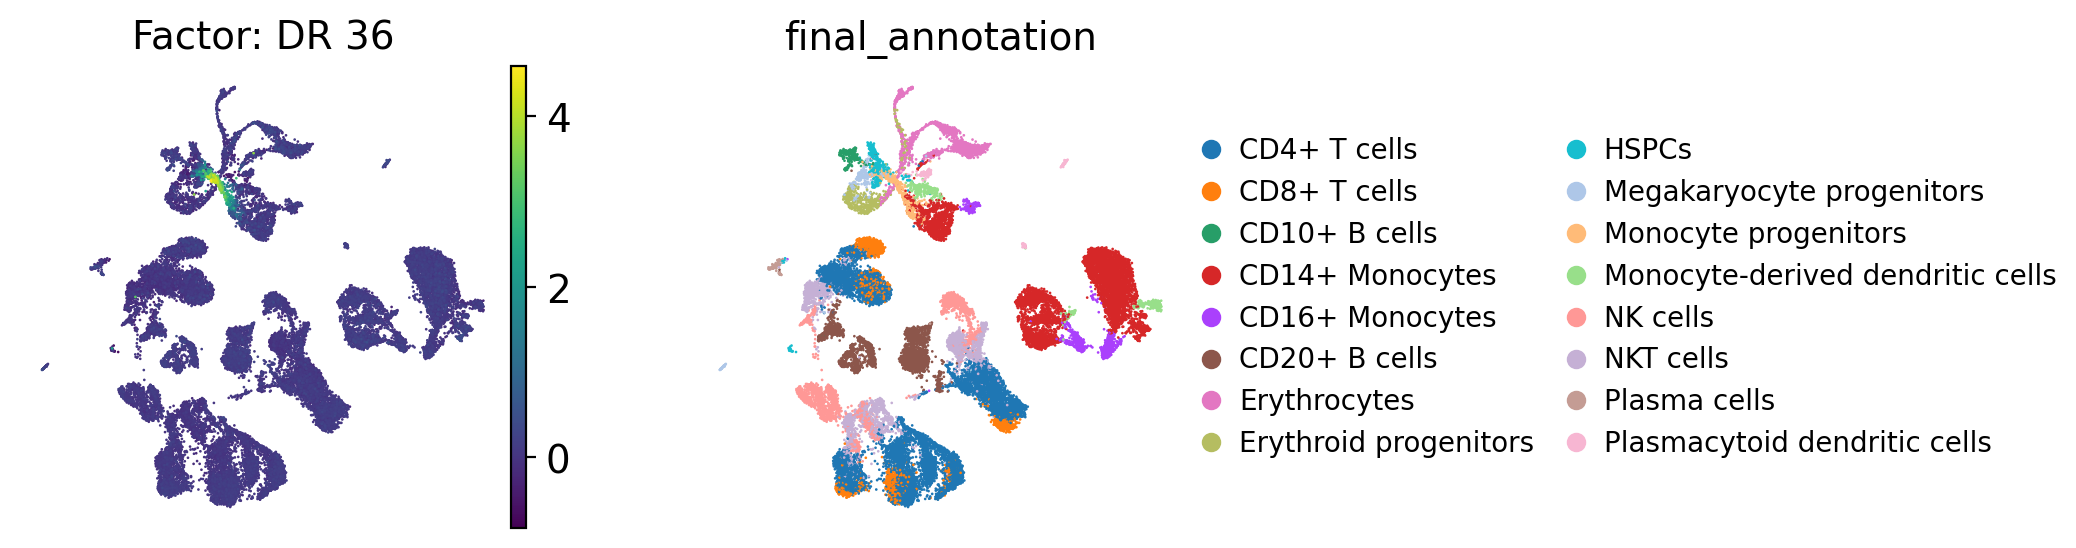

In [55]:
example_dims = ["DR 36"]  # Replace with factor-directions you want to visualize

if annot_col is not None and example_dims:
    drvi_factors_df = pd.DataFrame(embed_nv.X, index=embed_nv.obs_names, columns=factor_ids)
    for dim in example_dims:
        if dim in drvi_factors_df.columns:
            adata.obs["_factor_check"] = drvi_factors_df[dim].reindex(adata.obs_names).values
            annot = embed.var.set_index("title").loc[dim, "annotation_final"]
            print(f"\n{dim} — annotated as: {annot}")

            sc.pl.umap(
                adata,
                color=["_factor_check", annot_col],
                ncols=2,
                frameon=False,
                title=[f"Factor: {dim}", annot_col],
            )


## Appendix: Database reference

The table below lists curated databases available for factor annotation, organized by domain. You can swap any of the tool-specific config variables above (e.g., `gsea_db`, `gp_source`, `dc_geneset`) to use different databases.


### Biological process databases

| Database | Description | BlitzGSEA| g:Profiler | 
|----------|-------------|-------------------|------------|
| MSigDB Hallmark | 50 well curated non redundant biological states | `MSigDB_Hallmark_2020` | — |
| GO Biological Process | Comprehensive hierarchical processes | `GO_Biological_Process_2025` | `GO:BP` |
| GO Cellular Component | Subcellular localization | `GO_Cellular_Component_2025` | `GO:CC` |
| GO Molecular Function | Molecular activities | `GO_Molecular_Function_2025` | `GO:MF` |
| Reactome | Detailed, reaction-based pathways | `Reactome_Pathways_2024` | `REAC` |
| KEGG | Classic metabolic/signaling maps | `KEGG_2026` | `KEGG` | 
| WikiPathways | Community-curated biological maps | `WikiPathways_2024_Human` | `WP` |

### Regulatory networks (decoupler only)

| Network | Description | decoupler name | Notes|
|---------|-------------|---------------|---------|
| CollecTRI | TF → target gene regulons| `collectri` | Recommended for identifying TF drivers of a factor |
| PROGENy | Pathway-responsive genes signatures | `progeny` | Best for signaling (TGFb, MAPK, etc.) activity |
| DoRothEA |  TF → target gene interactions | `dorothea` |  Curated resource for Transcription Factor (TF) activity; uses confidence levels (A-D) |

### Clinical and Disease Phenotypes

| Database | Description | BlitzGSEA| g:Profiler |
|----------|-------------|-------------------|------------|
| Human Phenotype Ont. | Genes linked to clinical signs | Human_Phenotype_Ontology | HP |
| OMIM | Human genes and genetic disorders | OMIM_Disease | OMIM
